# IC3392 SFH and Stellar-Mass Check

Compare the new SFH/mass products from `9100/40 use` against the same-binning `7000/53` reference run.

Residual convention in this notebook: `9100/40 use - 7000/53 samebin`. For `E(B-V)` this is a direct color-excess difference; for `LOGMASS_SURFACE_DENSITY` this is a dex difference.

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from IPython.display import display

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 160,
    'axes.grid': False,
    'font.size': 10,
})

root = Path('/Users/Igniz/Desktop/ICRAR/further')

RUNS = {
    'use': {
        'label': '9100/40 use',
        'path': root / 'v3tk_v7.6.8_VELSCALE40_use' / 'IC3392',
        'sfh_file': 'IC3392_sfh_maps.fits',
        'extended_file': 'IC3392_spatial_binning_maps_extended.fits',
        'log_file': Path('mass_logs') / 'IC3392.log',
    },
    'samebin': {
        'label': '7000/53 samebin',
        'path': root / 'v3tk_v7.6.8_7000_samebinning' / 'IC3392',
        'sfh_file': 'IC3392_sfh_maps.fits',
        'extended_file': 'IC3392_spatial_binning_maps_extended.fits',
        'log_file': Path('mass_logs') / 'IC3392.log',
    },
}

MAP_ORDER = ['use', 'samebin']
REF_KEY = 'samebin'
TEST_KEY = 'use'

PROPERTIES = {
    'EBV': {
        'label': 'E(B-V)',
        'file_key': 'sfh_file',
        'hdu': 'EBV',
        'unit': 'mag',
        'cmap': 'magma',
    },
    'LOGMASS_SURFACE_DENSITY': {
        'label': 'log stellar mass surface density',
        'file_key': 'extended_file',
        'hdu': 'LOGMASS_SURFACE_DENSITY',
        'unit': 'log10(M_sun/kpc^2)',
        'cmap': 'viridis',
    },
}

for run in RUNS.values():
    for key in ('sfh_file', 'extended_file'):
        path = run['path'] / run[key]
        if not path.exists():
            raise FileNotFoundError(path)
    log_path = run['path'] / run['log_file']
    if not log_path.exists():
        raise FileNotFoundError(log_path)

print('Configured runs:')
for key, run in RUNS.items():
    print(f"  {key:7s}: {run['label']} -> {run['path']}")

Configured runs:
  use    : 9100/40 use -> /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8_VELSCALE40_use/IC3392
  samebin: 7000/53 samebin -> /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8_7000_samebinning/IC3392


## Load Products And Check Shared Binning

In [2]:
def read_image(path, hdu):
    with fits.open(path, memmap=True) as hdul:
        if hdu not in hdul:
            names = [ext.name for ext in hdul]
            raise KeyError(f"HDU {hdu!r} not found in {path}. Available: {names}")
        data = np.array(hdul[hdu].data, dtype=float)
        header = hdul[hdu].header.copy()
    return data, header


def robust_limits(values, p=(2, 98), pad_fraction=0.04, fallback=(0.0, 1.0)):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return fallback
    lo, hi = np.nanpercentile(arr, p)
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        center = np.nanmedian(arr)
        spread = np.nanstd(arr)
        if not np.isfinite(spread) or spread == 0:
            spread = 1.0
        lo, hi = center - spread, center + spread
    pad = (hi - lo) * pad_fraction
    return lo - pad, hi + pad


def symmetric_limits(values, p=98, fallback=(-1.0, 1.0)):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return fallback
    lim = np.nanpercentile(np.abs(arr), p)
    if not np.isfinite(lim) or lim == 0:
        lim = np.nanmax(np.abs(arr))
    if not np.isfinite(lim) or lim == 0:
        return fallback
    return -lim, lim


def finite_limits(values, fallback=(0.0, 1.0)):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return fallback
    lo = np.nanmin(arr)
    hi = np.nanmax(arr)
    if not np.isfinite(lo) or not np.isfinite(hi):
        return fallback
    if lo == hi:
        pad = max(abs(lo) * 0.01, 1e-6)
        return lo - pad, hi + pad
    return lo, hi


def as_common_nan_equal(a, b):
    return np.array_equal(np.isnan(a), np.isnan(b)) and np.array_equal(a[np.isfinite(a)], b[np.isfinite(b)])


data = {}
headers = {}
for run_key, run in RUNS.items():
    data[run_key] = {}
    headers[run_key] = {}
    binid, binid_header = read_image(run['path'] / run['extended_file'], 'BINID')
    data[run_key]['BINID'] = binid
    headers[run_key]['BINID'] = binid_header
    for prop_key, prop in PROPERTIES.items():
        path = run['path'] / run[prop['file_key']]
        arr, hdr = read_image(path, prop['hdu'])
        data[run_key][prop_key] = arr
        headers[run_key][prop_key] = hdr

shape_rows = []
for run_key, run in RUNS.items():
    for key in ['BINID', *PROPERTIES.keys()]:
        arr = data[run_key][key]
        shape_rows.append({
            'run': run['label'],
            'map': key,
            'shape': arr.shape,
            'finite_pixels': int(np.isfinite(arr).sum()),
            'min': np.nanmin(arr),
            'median': np.nanmedian(arr),
            'max': np.nanmax(arr),
        })
shape_summary = pd.DataFrame(shape_rows)
display(shape_summary)

binid_same = as_common_nan_equal(data[TEST_KEY]['BINID'], data[REF_KEY]['BINID'])
COMPARISON_BASIS = 'matched spatial bins' if binid_same else 'common finite pixels'
print(f"BINID maps exactly match including NaN mask: {binid_same}")
print(f"Comparison table basis: {COMPARISON_BASIS}")
print(f"Unique finite bins in {RUNS[TEST_KEY]['label']}: {np.unique(data[TEST_KEY]['BINID'][np.isfinite(data[TEST_KEY]['BINID'])]).size}")
print(f"Unique finite bins in {RUNS[REF_KEY]['label']}: {np.unique(data[REF_KEY]['BINID'][np.isfinite(data[REF_KEY]['BINID'])]).size}")

,run,map,shape,finite_pixels,min,median,max
0,9100/40 use,BINID,"(438, 437)",94543,0.000000,2888.000000,4031.000000
1,9100/40 use,EBV,"(438, 437)",94543,0.000000,0.000000,0.299974
2,9100/40 use,LOGMASS_SURFACE_DENSITY,"(438, 437)",94543,7.042243,7.805833,9.325187
3,7000/53 samebin,BINID,"(438, 437)",94543,0.000000,2888.000000,4031.000000
4,7000/53 samebin,EBV,"(438, 437)",94543,0.000000,0.053431,0.386430
5,7000/53 samebin,LOGMASS_SURFACE_DENSITY,"(438, 437)",94543,6.371791,7.666137,9.417749


BINID maps exactly match including NaN mask: True
Comparison table basis: matched spatial bins
Unique finite bins in 9100/40 use: 4032
Unique finite bins in 7000/53 samebin: 4032


## E(B-V) And Stellar-Mass Maps

Each row uses one color scale shared by the two runs, so spatial differences are not hidden by independent normalization.

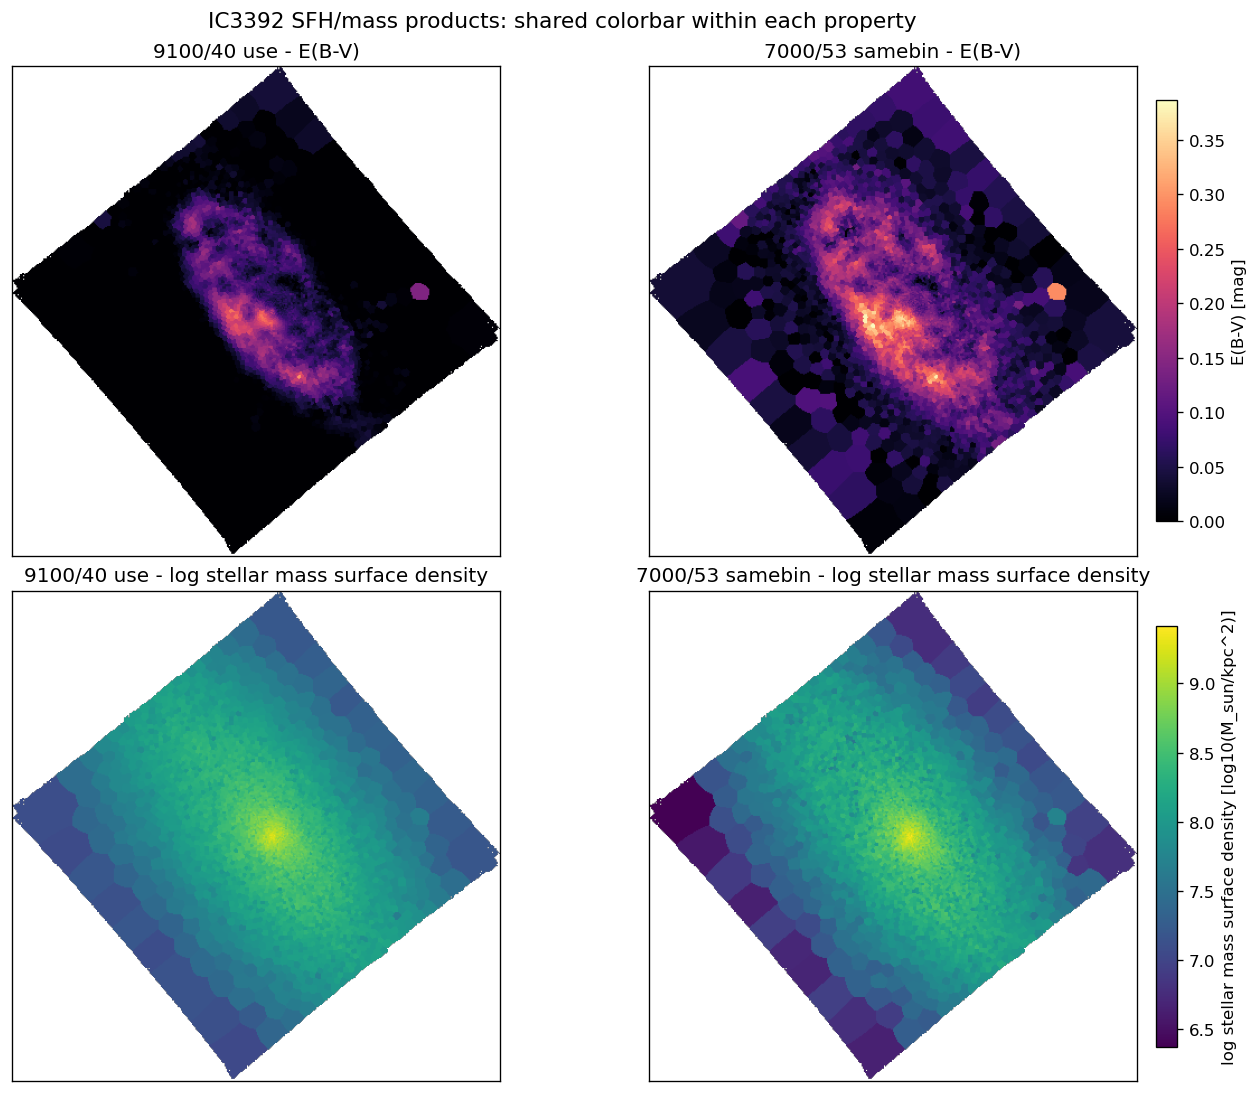

In [3]:
fig, axes = plt.subplots(len(PROPERTIES), len(MAP_ORDER), figsize=(11.5, 9.0), constrained_layout=True)
if axes.ndim == 1:
    axes = axes[None, :]

for row, (prop_key, prop) in enumerate(PROPERTIES.items()):
    combined = np.concatenate([data[run_key][prop_key].ravel() for run_key in MAP_ORDER])
    vmin, vmax = finite_limits(combined)
    last_im = None
    for col, run_key in enumerate(MAP_ORDER):
        ax = axes[row, col]
        im = ax.imshow(data[run_key][prop_key], origin='lower', cmap=prop['cmap'], vmin=vmin, vmax=vmax)
        last_im = im
        ax.set_title(f"{RUNS[run_key]['label']} - {prop['label']}")
        ax.set_xticks([])
        ax.set_yticks([])
    cbar = fig.colorbar(last_im, ax=axes[row, :], shrink=0.86, pad=0.015)
    cbar.set_label(f"{prop['label']} [{prop['unit']}]")

fig.suptitle('IC3392 SFH/mass products: shared colorbar within each property', fontsize=13)
plt.show()

## Build Comparison Tables

When the two `BINID` maps match exactly, the comparison scatter/statistics use one row per spatial bin. When they do not match exactly, the helper falls back to one row per common finite pixel, so the pairwise plots and residual summaries still use the full overlapping map footprint. Residuals are always `9100/40 use - 7000/53 samebin`.

In [4]:
def per_bin_property_table(prop_key):
    test = data[TEST_KEY][prop_key]
    ref = data[REF_KEY][prop_key]
    test_bin = data[TEST_KEY]['BINID']
    ref_bin = data[REF_KEY]['BINID']

    if test.shape != ref.shape or test_bin.shape != ref_bin.shape:
        raise ValueError(f"Shape mismatch for {prop_key}: {test.shape} vs {ref.shape}")

    finite = np.isfinite(test) & np.isfinite(ref) & np.isfinite(test_bin) & np.isfinite(ref_bin)

    if binid_same:
        finite = finite & (test_bin == ref_bin)
        raw = pd.DataFrame({
            'binid_test': test_bin[finite].astype(int),
            'binid_ref': ref_bin[finite].astype(int),
            'test': test[finite],
            'ref': ref[finite],
        })
        grouped = raw.groupby('binid_test', sort=True).agg(
            binid_test=('binid_test', 'first'),
            binid_ref=('binid_ref', 'first'),
            test=('test', 'median'),
            ref=('ref', 'median'),
            n_pixels=('test', 'size'),
        ).reset_index(drop=True)
        grouped['comparison_unit'] = 'matched_bin'
    else:
        yy, xx = np.where(finite)
        grouped = pd.DataFrame({
            'binid_test': test_bin[finite].astype(int),
            'binid_ref': ref_bin[finite].astype(int),
            'x': xx,
            'y': yy,
            'test': test[finite],
            'ref': ref[finite],
            'n_pixels': 1,
            'comparison_unit': 'common_pixel',
        })

    grouped['residual'] = grouped['test'] - grouped['ref']
    grouped['prop_key'] = prop_key
    return grouped

comparison_tables = {prop_key: per_bin_property_table(prop_key) for prop_key in PROPERTIES}

for prop_key, table in comparison_tables.items():
    prop = PROPERTIES[prop_key]
    print(f"{prop['label']}: {len(table)} {COMPARISON_BASIS} represented")
    display_cols = ['binid_test', 'binid_ref', 'test', 'ref', 'residual', 'n_pixels', 'comparison_unit']
    if 'x' in table.columns and 'y' in table.columns:
        display_cols = ['x', 'y', *display_cols]
    display(table[display_cols].head())

E(B-V): 4032 matched spatial bins represented


,binid_test,binid_ref,test,ref,residual,n_pixels,comparison_unit
0,0,0,0.169090,0.242619,-0.073529,1,matched_bin
1,1,1,0.136297,0.210425,-0.074128,1,matched_bin
2,2,2,0.130520,0.203553,-0.073033,1,matched_bin
3,3,3,0.183374,0.239798,-0.056424,1,matched_bin
4,4,4,0.104080,0.182441,-0.078361,1,matched_bin


log stellar mass surface density: 4032 matched spatial bins represented


,binid_test,binid_ref,test,ref,residual,n_pixels,comparison_unit
0,0,0,9.188566,9.209839,-0.021274,1,matched_bin
1,1,1,9.325187,9.417749,-0.092562,1,matched_bin
2,2,2,9.249794,9.369337,-0.119543,1,matched_bin
3,3,3,9.237738,9.263803,-0.026065,1,matched_bin
4,4,4,9.167942,9.295761,-0.127819,1,matched_bin


## Pairwise And Residual Scatter Plots

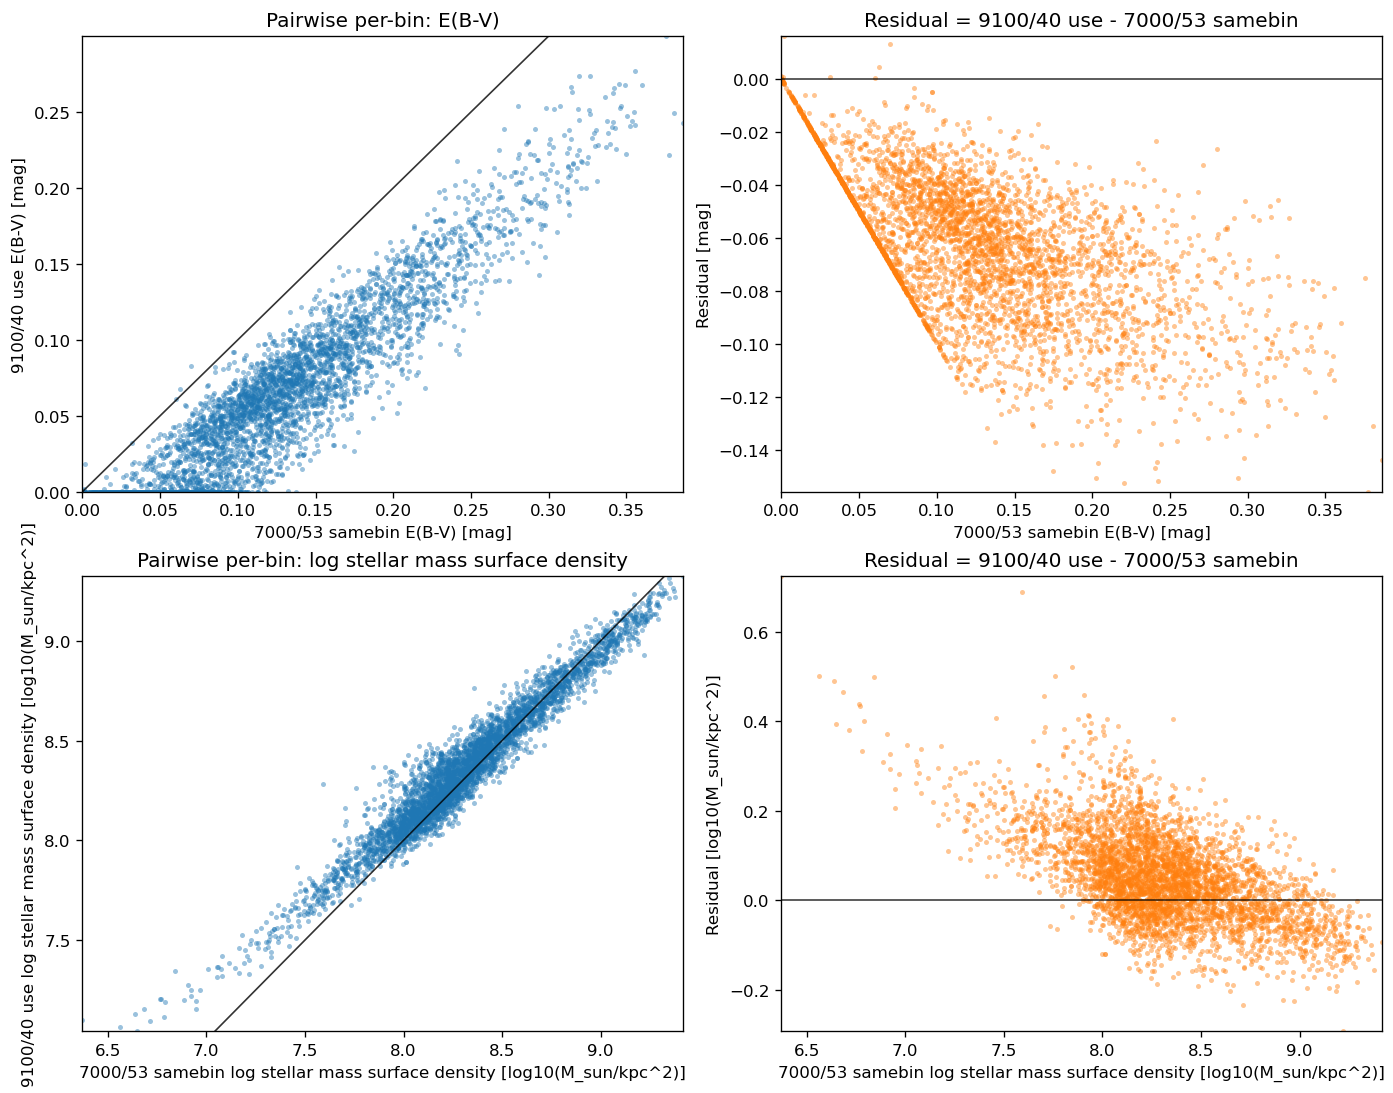

In [5]:
fig, axes = plt.subplots(len(PROPERTIES), 2, figsize=(11.5, 9.0), constrained_layout=True)
if axes.ndim == 1:
    axes = axes[None, :]

for row, (prop_key, prop) in enumerate(PROPERTIES.items()):
    table = comparison_tables[prop_key]
    x = table['ref'].to_numpy()
    y = table['test'].to_numpy()
    r = table['residual'].to_numpy()

    ax = axes[row, 0]
    ax.scatter(x, y, s=9, alpha=0.45, linewidths=0, color='tab:blue')
    xlo, xhi = finite_limits(x)
    ylo, yhi = finite_limits(y)
    line_lo = min(xlo, ylo)
    line_hi = max(xhi, yhi)
    ax.plot([line_lo, line_hi], [line_lo, line_hi], color='black', lw=1.0, alpha=0.8)
    ax.set_xlim(xlo, xhi)
    ax.set_ylim(ylo, yhi)
    ax.set_xlabel(f"{RUNS[REF_KEY]['label']} {prop['label']} [{prop['unit']}]")
    ax.set_ylabel(f"{RUNS[TEST_KEY]['label']} {prop['label']} [{prop['unit']}]")
    ax.set_title(f"Pairwise per-bin: {prop['label']}")

    ax = axes[row, 1]
    ax.axhline(0, color='black', lw=1.0, alpha=0.75)
    ax.scatter(x, r, s=9, alpha=0.45, linewidths=0, color='tab:orange')
    ylo, yhi = finite_limits(r)
    xlo, xhi = finite_limits(x)
    ax.set_xlim(xlo, xhi)
    ax.set_ylim(ylo, yhi)
    ax.set_xlabel(f"{RUNS[REF_KEY]['label']} {prop['label']} [{prop['unit']}]")
    ax.set_ylabel(f"Residual [{prop['unit']}]")
    ax.set_title(f"Residual = {RUNS[TEST_KEY]['label']} - {RUNS[REF_KEY]['label']}")

plt.show()

## Residual Maps

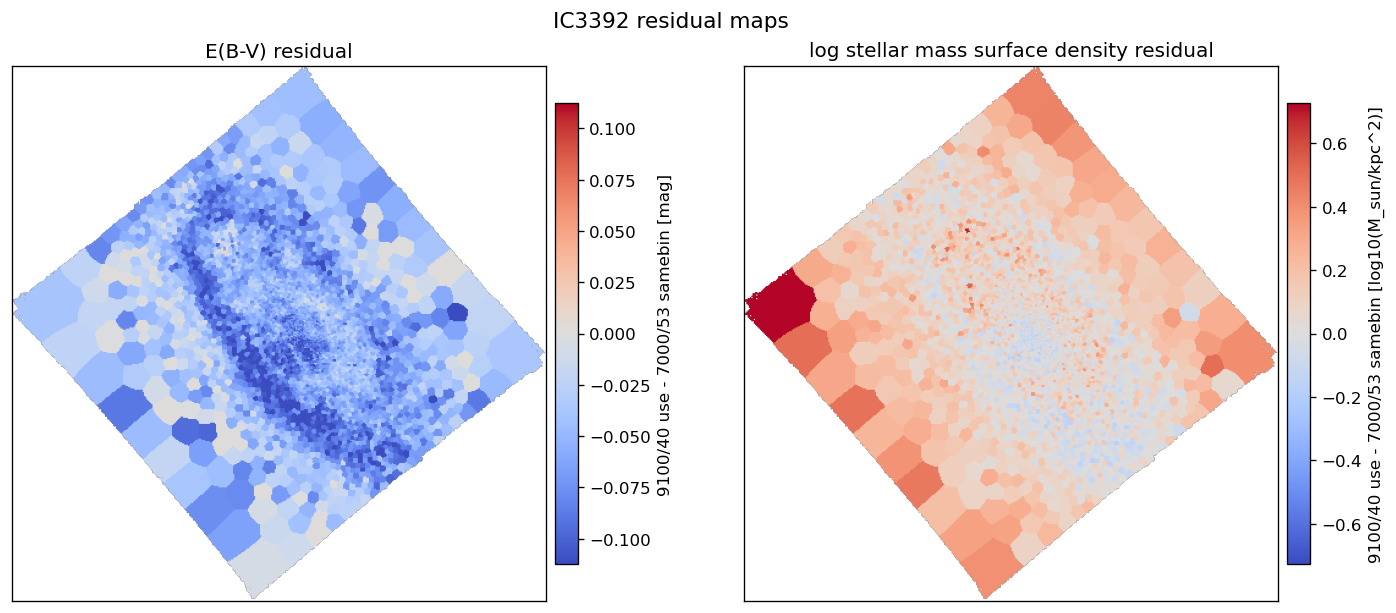

In [6]:
fig, axes = plt.subplots(1, len(PROPERTIES), figsize=(12.0, 5.0), constrained_layout=True)
if len(PROPERTIES) == 1:
    axes = [axes]

residual_maps = {}
for ax, (prop_key, prop) in zip(axes, PROPERTIES.items()):
    residual = data[TEST_KEY][prop_key] - data[REF_KEY][prop_key]
    residual_maps[prop_key] = residual
    vmin, vmax = symmetric_limits(residual)
    im = ax.imshow(residual, origin='lower', cmap='coolwarm', vmin=vmin, vmax=vmax)
    ax.set_title(f"{prop['label']} residual")
    ax.set_xticks([])
    ax.set_yticks([])
    cbar = fig.colorbar(im, ax=ax, shrink=0.86, pad=0.015)
    cbar.set_label(f"{RUNS[TEST_KEY]['label']} - {RUNS[REF_KEY]['label']} [{prop['unit']}]")

fig.suptitle('IC3392 residual maps', fontsize=13)
plt.show()

## Residual Summary Statistics

In [7]:
def nmad(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    med = np.nanmedian(values)
    return 1.4826 * np.nanmedian(np.abs(values - med))

summary_rows = []
for prop_key, prop in PROPERTIES.items():
    table = comparison_tables[prop_key]
    residual = table['residual'].to_numpy()
    summary_rows.append({
        'property': prop['label'],
        'unit': prop['unit'],
        'comparison_basis': COMPARISON_BASIS,
        'n_comparison_points': len(table),
        f"median_{RUNS[REF_KEY]['label']}": np.nanmedian(table['ref']),
        f"median_{RUNS[TEST_KEY]['label']}": np.nanmedian(table['test']),
        'median_residual_use_minus_samebin': np.nanmedian(residual),
        'mean_residual_use_minus_samebin': np.nanmean(residual),
        'nmad_residual': nmad(residual),
        'p16_residual': np.nanpercentile(residual, 16),
        'p84_residual': np.nanpercentile(residual, 84),
        'p02_residual': np.nanpercentile(residual, 2),
        'p98_residual': np.nanpercentile(residual, 98),
    })

residual_summary = pd.DataFrame(summary_rows)
display(residual_summary)

for _, row in residual_summary.iterrows():
    print(
        f"{row['property']}: median residual = {row['median_residual_use_minus_samebin']:.4g} "
        f"{row['unit']}, NMAD = {row['nmad_residual']:.4g} {row['unit']}"
    )

,property,unit,comparison_basis,n_comparison_points,median_7000/53 samebin,median_9100/40 use,median_residual_use_minus_samebin,mean_residual_use_minus_samebin,nmad_residual,p16_residual,p84_residual,p02_residual,p98_residual
0,E(B-V),mag,matched spatial bins,4032,0.116813,0.055990,-0.060447,-0.061870,0.026580,-0.089996,-0.03531,-0.117626,-0.007521
1,log stellar mass surface density,log10(M_sun/kpc^2),matched spatial bins,4032,8.278674,8.343288,0.040575,0.049479,0.095582,-0.046002,0.14470,-0.131391,0.290827


E(B-V): median residual = -0.06045 mag, NMAD = 0.02658 mag
log stellar mass surface density: median residual = 0.04057 log10(M_sun/kpc^2), NMAD = 0.09558 log10(M_sun/kpc^2)


## Largest Per-Bin Residuals

In [8]:
largest_residual_tables = {}
for prop_key, prop in PROPERTIES.items():
    table = comparison_tables[prop_key].copy()
    table['abs_residual'] = table['residual'].abs()
    table = table.sort_values('abs_residual', ascending=False).head(12)
    table = table.rename(columns={
        'test': RUNS[TEST_KEY]['label'],
        'ref': RUNS[REF_KEY]['label'],
    })
    largest_residual_tables[prop_key] = table
    print(f"Largest absolute residual bins: {prop['label']}")
    display(table[['binid_test', 'binid_ref', RUNS[TEST_KEY]['label'], RUNS[REF_KEY]['label'], 'residual', 'abs_residual', 'n_pixels']])

Largest absolute residual bins: E(B-V)


,binid_test,binid_ref,9100/40 use,7000/53 samebin,residual,abs_residual,n_pixels
468,468,468,0.221685,0.377543,-0.155858,0.155858,15
670,670,670,0.067992,0.220481,-0.152489,0.152489,14
2901,2901,2901,0.090651,0.242379,-0.151728,0.151728,9
3916,3916,3916,0.142777,0.293624,-0.150847,0.150847,208
695,695,695,0.051616,0.202212,-0.150597,0.150597,12
520,520,520,0.026991,0.174877,-0.147886,0.147886,18
779,779,779,0.093040,0.240144,-0.147104,0.147104,13
636,636,636,0.058449,0.203594,-0.145145,0.145145,16
480,480,480,0.096871,0.241433,-0.144561,0.144561,12
402,402,402,0.242711,0.386430,-0.143719,0.143719,13


Largest absolute residual bins: log stellar mass surface density


,binid_test,binid_ref,9100/40 use,7000/53 samebin,residual,abs_residual,n_pixels
2431,2431,2431,7.097764,6.371791,0.725973,0.725973,2074
2433,2433,2433,8.283103,7.592783,0.690320,0.690320,10
1103,1103,1103,8.367447,7.844654,0.522793,0.522793,16
1288,1288,1288,7.064512,6.562491,0.502021,0.502021,1239
1737,1737,1737,8.260663,7.759576,0.501087,0.501087,12
4022,4022,4022,7.343432,6.843016,0.500416,0.500416,256
868,868,868,7.129196,6.639378,0.489818,0.489818,1000
873,873,873,7.152966,6.686374,0.466592,0.466592,869
962,962,962,8.366243,7.908073,0.458170,0.458170,6
2505,2505,2505,8.162013,7.704319,0.457694,0.457694,7


## Mass-Log Total Properties

The mass logs contain integrated quantities and implementation notes. This parser keeps the comparison auditable by reading the log text directly.

In [9]:
LOG_PATTERNS = {
    'selected_ML_R_interpretation': r'Selected SFH-weight interpretation for ML_R:\s*(.+)',
    'total_R_mag_uncorrected_AB': r'Total R-band magnitude \(uncorrected\)\s*:\s*([-+0-9.eE]+)',
    'total_R_mag_corrected_AB': r'Total R-band magnitude \(corrected\)\s*:\s*([-+0-9.eE]+)',
    'total_R_luminosity_log10_Lsun': r'Total R-band luminosity\s*:\s*([-+0-9.eE]+)',
    'total_stellar_mass_log10_Msun': r'Total stellar mass \(R\)\s*:\s*([-+0-9.eE]+)',
    'integrated_ML_R_Msun_per_Lsun': r'Integrated stellar M/L_R\s*:\s*([-+0-9.eE]+)',
    'median_LOGMSTAR_ERR_dex': r'Median LOGMSTAR_ERR\s*:\s*([-+0-9.eE]+)',
    'median_LOGMASS_SURFACE_DENSITY_ERR_dex': r'Median LOGMASS_SURFACE_DENSITY_ERR:\s*([-+0-9.eE]+)',
    'inclination_correction': r'Inclination correction ([^:]+):\s*(.+)',
}


def parse_mass_log(path):
    text = Path(path).read_text(errors='replace')
    row = {}
    for key, pattern in LOG_PATTERNS.items():
        match = re.search(pattern, text)
        if not match:
            row[key] = np.nan
            continue
        if key == 'inclination_correction':
            row[key] = f"{match.group(1).strip()}: {match.group(2).strip()}"
        else:
            value = match.group(1).strip()
            try:
                row[key] = float(value)
            except ValueError:
                row[key] = value
    return row

log_rows = []
for run_key, run in RUNS.items():
    parsed = parse_mass_log(run['path'] / run['log_file'])
    parsed['run'] = run['label']
    parsed['log_path'] = str(run['path'] / run['log_file'])
    log_rows.append(parsed)

log_summary = pd.DataFrame(log_rows).set_index('run')
display(log_summary.T)

numeric_metrics = log_summary.select_dtypes(include=[np.number]).columns
log_delta = (log_summary.loc[RUNS[TEST_KEY]['label'], numeric_metrics] - log_summary.loc[RUNS[REF_KEY]['label'], numeric_metrics]).rename('use_minus_samebin')
display(log_delta.to_frame())

run,9100/40 use,7000/53 samebin
selected_ML_R_interpretation,light_v_to_r,light_v_to_r
total_R_mag_uncorrected_AB,12.26,12.26
total_R_mag_corrected_AB,12.077,11.865
total_R_luminosity_log10_Lsun,9.448,9.533
total_stellar_mass_log10_Msun,9.779,9.721
integrated_ML_R_Msun_per_Lsun,2.1402,1.5402
median_LOGMSTAR_ERR_dex,0.000244,0.000244
median_LOGMASS_SURFACE_DENSITY_ERR_dex,0.000244,0.000244
inclination_correction,ENABLED: applying b/a = 0.418 (adopting intrin...,ENABLED: applying b/a = 0.418 (adopting intrin...
log_path,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...


,use_minus_samebin
total_R_mag_uncorrected_AB,0.0
total_R_mag_corrected_AB,0.212
total_R_luminosity_log10_Lsun,-0.085
total_stellar_mass_log10_Msun,0.058
integrated_ML_R_Msun_per_Lsun,0.6
median_LOGMSTAR_ERR_dex,0.0
median_LOGMASS_SURFACE_DENSITY_ERR_dex,0.0


## SFH Weight Grid Heatmaps

The `IC3392_sfh_weights.fits` files store one normalized template-weight vector per spatial bin, and the `GRID` table gives the corresponding `LOGAGE`, `METAL`, and `ALPHA` values. Here the heatmap uses the equal-bin average weight on the age-metallicity grid, marginalizing over `ALPHA` if needed. The FITS grid stores age as `LOGAGE`, but the heatmap x-axis is labelled in linear age, `10**LOGAGE` Gyr, because that is easier to read. In these files `ALPHA` is constant at `0.0`, so the heatmap is effectively the native age-metallicity grid.

In [10]:
def read_sfh_weights(run_key):
    path = RUNS[run_key]['path'] / 'IC3392_sfh_weights.fits'
    with fits.open(path, memmap=True) as hdul:
        weights = np.array(hdul['WEIGHTS'].data['WEIGHTS'], dtype=float)
        grid_data = hdul['GRID'].data
        grid = pd.DataFrame({name: np.array(grid_data[name], dtype=float) for name in grid_data.names})
    return weights, grid


def make_age_metal_weight_table(weights, grid):
    table = grid.copy()
    table['mean_weight'] = np.nanmean(weights, axis=0)
    total = table['mean_weight'].sum()
    if np.isfinite(total) and total > 0:
        table['mean_weight'] = table['mean_weight'] / total
    # If there were multiple alpha values, this would marginalize over alpha.
    return table.groupby(['LOGAGE', 'METAL'], as_index=False)['mean_weight'].sum()


def centers_to_edges(values):
    values = np.sort(np.asarray(values, dtype=float))
    if len(values) == 1:
        step = 0.5
        return np.array([values[0] - step, values[0] + step])
    mids = 0.5 * (values[:-1] + values[1:])
    first = values[0] - (mids[0] - values[0])
    last = values[-1] + (values[-1] - mids[-1])
    return np.concatenate([[first], mids, [last]])


def table_to_matrix(table, value_col='mean_weight'):
    logage_centers = np.sort(table['LOGAGE'].unique())
    age_centers_gyr = 10 ** logage_centers
    metals = np.sort(table['METAL'].unique())
    pivot = table.pivot(index='METAL', columns='LOGAGE', values=value_col).reindex(index=metals, columns=logage_centers)
    return age_centers_gyr, metals, pivot.to_numpy(dtype=float)


def summarize_weight_table(table):
    logage = table['LOGAGE'].to_numpy(dtype=float)
    age_gyr = 10 ** logage
    metal = table['METAL'].to_numpy(dtype=float)
    weight = table['mean_weight'].to_numpy(dtype=float)
    top = table.loc[table['mean_weight'].idxmax()]
    return {
        'mean_logage': np.sum(weight * logage),
        'mean_age_Gyr': np.sum(weight * age_gyr),
        'mean_metal': np.sum(weight * metal),
        'frac_age_lt_2Gyr': weight[age_gyr < 2].sum(),
        'frac_age_2_to_8Gyr': weight[(age_gyr >= 2) & (age_gyr < 8)].sum(),
        'frac_age_ge_8Gyr': weight[age_gyr >= 8].sum(),
        'frac_metal_lt_minus0p5': weight[metal < -0.5].sum(),
        'frac_metal_gt_minus0p25': weight[metal > -0.25].sum(),
        'top_LOGAGE': top['LOGAGE'],
        'top_age_Gyr': 10 ** top['LOGAGE'],
        'top_METAL': top['METAL'],
        'top_weight': top['mean_weight'],
    }

sfh_weights = {}
sfh_grids = {}
sfh_weight_tables = {}
for run_key in MAP_ORDER:
    weights, grid = read_sfh_weights(run_key)
    sfh_weights[run_key] = weights
    sfh_grids[run_key] = grid
    sfh_weight_tables[run_key] = make_age_metal_weight_table(weights, grid)
    print(
        f"{RUNS[run_key]['label']}: weights shape={weights.shape}, "
        f"row-sum median={np.nanmedian(weights.sum(axis=1)):.6f}, "
        f"LOGAGE bins={grid['LOGAGE'].nunique()}, METAL bins={grid['METAL'].nunique()}, ALPHA bins={grid['ALPHA'].nunique()}"
    )

same_template_grid = (
    sfh_grids[TEST_KEY].shape == sfh_grids[REF_KEY].shape
    and np.allclose(sfh_grids[TEST_KEY][['LOGAGE', 'METAL', 'ALPHA']], sfh_grids[REF_KEY][['LOGAGE', 'METAL', 'ALPHA']])
)
print(f"Template grids match exactly within numerical tolerance: {same_template_grid}")

sfh_weight_summary = pd.DataFrame({
    RUNS[run_key]['label']: summarize_weight_table(table)
    for run_key, table in sfh_weight_tables.items()
}).T
display(sfh_weight_summary)

merged_weight_grid = sfh_weight_tables[TEST_KEY].merge(
    sfh_weight_tables[REF_KEY],
    on=['LOGAGE', 'METAL'],
    suffixes=('_use', '_samebin'),
)
merged_weight_grid['age_Gyr'] = 10 ** merged_weight_grid['LOGAGE']
merged_weight_grid['residual_use_minus_samebin'] = merged_weight_grid['mean_weight_use'] - merged_weight_grid['mean_weight_samebin']

weight_grid_display_cols = ['age_Gyr', 'LOGAGE', 'METAL', 'mean_weight_use', 'mean_weight_samebin', 'residual_use_minus_samebin']
print('Largest positive age-metal weight residual cells:')
display(merged_weight_grid.sort_values('residual_use_minus_samebin', ascending=False)[weight_grid_display_cols].head(10))
print('Largest negative age-metal weight residual cells:')
display(merged_weight_grid.sort_values('residual_use_minus_samebin')[weight_grid_display_cols].head(10))

9100/40 use: weights shape=(4032, 477), row-sum median=1.000000, LOGAGE bins=53, METAL bins=9, ALPHA bins=1
7000/53 samebin: weights shape=(4032, 477), row-sum median=1.000000, LOGAGE bins=53, METAL bins=9, ALPHA bins=1
Template grids match exactly within numerical tolerance: True


,mean_logage,mean_age_Gyr,mean_metal,frac_age_lt_2Gyr,frac_age_2_to_8Gyr,frac_age_ge_8Gyr,frac_metal_lt_minus0p5,frac_metal_gt_minus0p25,top_LOGAGE,top_age_Gyr,top_METAL,top_weight
9100/40 use,0.608695,7.749983,-0.292030,0.314092,0.115933,0.569974,0.314265,0.577587,1.09691,12.50,0.26,0.105991
7000/53 samebin,0.333943,5.320986,-0.243404,0.498776,0.134116,0.367108,0.308718,0.598901,0.09691,1.25,0.26,0.034102


Largest positive age-metal weight residual cells:


,age_Gyr,LOGAGE,METAL,mean_weight_use,mean_weight_samebin,residual_use_minus_samebin
449,12.50,1.096910,0.26,0.105991,0.006120,0.099871
468,14.00,1.146128,-1.49,0.066153,0.007047,0.059105
401,10.00,1.000000,-0.25,0.049797,0.002084,0.047713
476,14.00,1.146128,0.26,0.070147,0.032265,0.037882
469,14.00,1.146128,-1.26,0.038720,0.004974,0.033746
359,7.50,0.875061,0.26,0.030559,0.001302,0.029257
397,10.00,1.000000,-1.26,0.036387,0.011084,0.025304
215,1.75,0.243038,0.26,0.027906,0.006948,0.020958
396,10.00,1.000000,-1.49,0.020643,0.000722,0.019921
446,12.50,1.096910,-0.25,0.018242,0.000197,0.018045


Largest negative age-metal weight residual cells:


,age_Gyr,LOGAGE,METAL,mean_weight_use,mean_weight_samebin,residual_use_minus_samebin
195,1.25,0.096910,0.06,0.000000e+00,0.029917,-0.029917
186,1.00,0.000000,0.06,1.887962e-04,0.028276,-0.028087
375,8.50,0.929419,0.06,5.994733e-04,0.023555,-0.022956
196,1.25,0.096910,0.15,5.992887e-05,0.020162,-0.020102
472,14.00,1.146128,-0.35,5.390518e-05,0.017970,-0.017916
177,0.90,-0.045757,0.06,1.403205e-04,0.015981,-0.015840
191,1.25,0.096910,-0.96,4.872864e-04,0.015660,-0.015172
160,0.70,-0.154902,0.15,1.710300e-02,0.032094,-0.014991
384,9.00,0.954243,0.06,4.033702e-04,0.011264,-0.010860
3,0.03,-1.522879,-0.66,8.677399e-09,0.009754,-0.009754


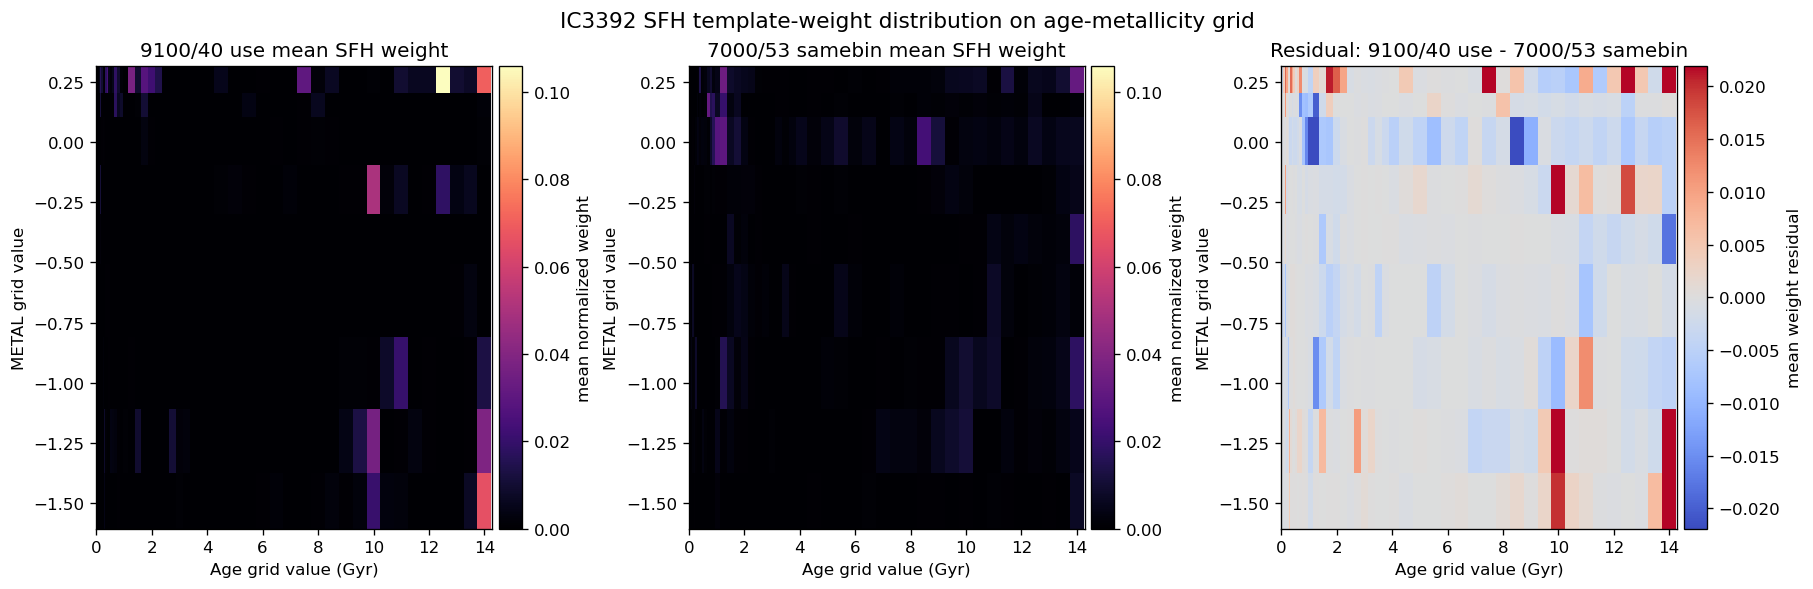

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.8), constrained_layout=True)

matrices = {}
for run_key in MAP_ORDER:
    age_centers_gyr, metals, matrix = table_to_matrix(sfh_weight_tables[run_key])
    matrices[run_key] = matrix
age_edges = centers_to_edges(age_centers_gyr)
metal_edges = centers_to_edges(metals)
shared_vmax = np.nanmax(np.concatenate([matrices[run_key].ravel() for run_key in MAP_ORDER]))
if not np.isfinite(shared_vmax) or shared_vmax <= 0:
    shared_vmax = 1.0

for ax, run_key in zip(axes[:2], MAP_ORDER):
    im = ax.pcolormesh(age_edges, metal_edges, matrices[run_key], cmap='magma', vmin=0, vmax=shared_vmax, shading='auto')
    ax.set_title(f"{RUNS[run_key]['label']} mean SFH weight")
    ax.set_xlabel('Age grid value (Gyr)')
    ax.set_ylabel('METAL grid value')
    ax.set_xlim(0, np.nanmax(age_centers_gyr) * 1.02)
    ax.set_xticks([0, 2, 4, 6, 8, 10, 12, 14])
    fig.colorbar(im, ax=ax, pad=0.01, label='mean normalized weight')

residual_matrix = matrices[TEST_KEY] - matrices[REF_KEY]
rmin, rmax = symmetric_limits(residual_matrix)
im = axes[2].pcolormesh(age_edges, metal_edges, residual_matrix, cmap='coolwarm', vmin=rmin, vmax=rmax, shading='auto')
axes[2].set_title(f"Residual: {RUNS[TEST_KEY]['label']} - {RUNS[REF_KEY]['label']}")
axes[2].set_xlabel('Age grid value (Gyr)')
axes[2].set_ylabel('METAL grid value')
axes[2].set_xlim(0, np.nanmax(age_centers_gyr) * 1.02)
axes[2].set_xticks([0, 2, 4, 6, 8, 10, 12, 14])
fig.colorbar(im, ax=axes[2], pad=0.01, label='mean weight residual')

fig.suptitle('IC3392 SFH template-weight distribution on age-metallicity grid', fontsize=13)
plt.show()

## SFH Age And Metallicity Map Diagnostics

The previous heatmap collapses the galaxy to an average template-weight distribution. These panels check whether the fitted `AGE` and `METAL` image products show the same kind of run-to-run shift spatially. Residuals are again `9100/40 use - 7000/53 samebin`. The pairwise tables use matched spatial bins when the two `BINID` maps are identical, otherwise common finite pixels.

,property,unit,comparison_basis,n_comparison_points,median_7000/53 samebin,median_9100/40 use,median_residual_use_minus_samebin,mean_residual_use_minus_samebin,nmad_residual,p16_residual,p84_residual,corrcoef,n_positive_residual,n_negative_residual
0,SFH age,Gyr,matched spatial bins,4032,5.242486,7.637844,2.323704,2.428997,1.592643,0.783124,4.042018,0.619412,3770,262
1,SFH metallicity,dex,matched spatial bins,4032,-0.237954,-0.285609,-0.049761,-0.048626,0.103000,-0.150737,0.056173,0.756265,1275,2757


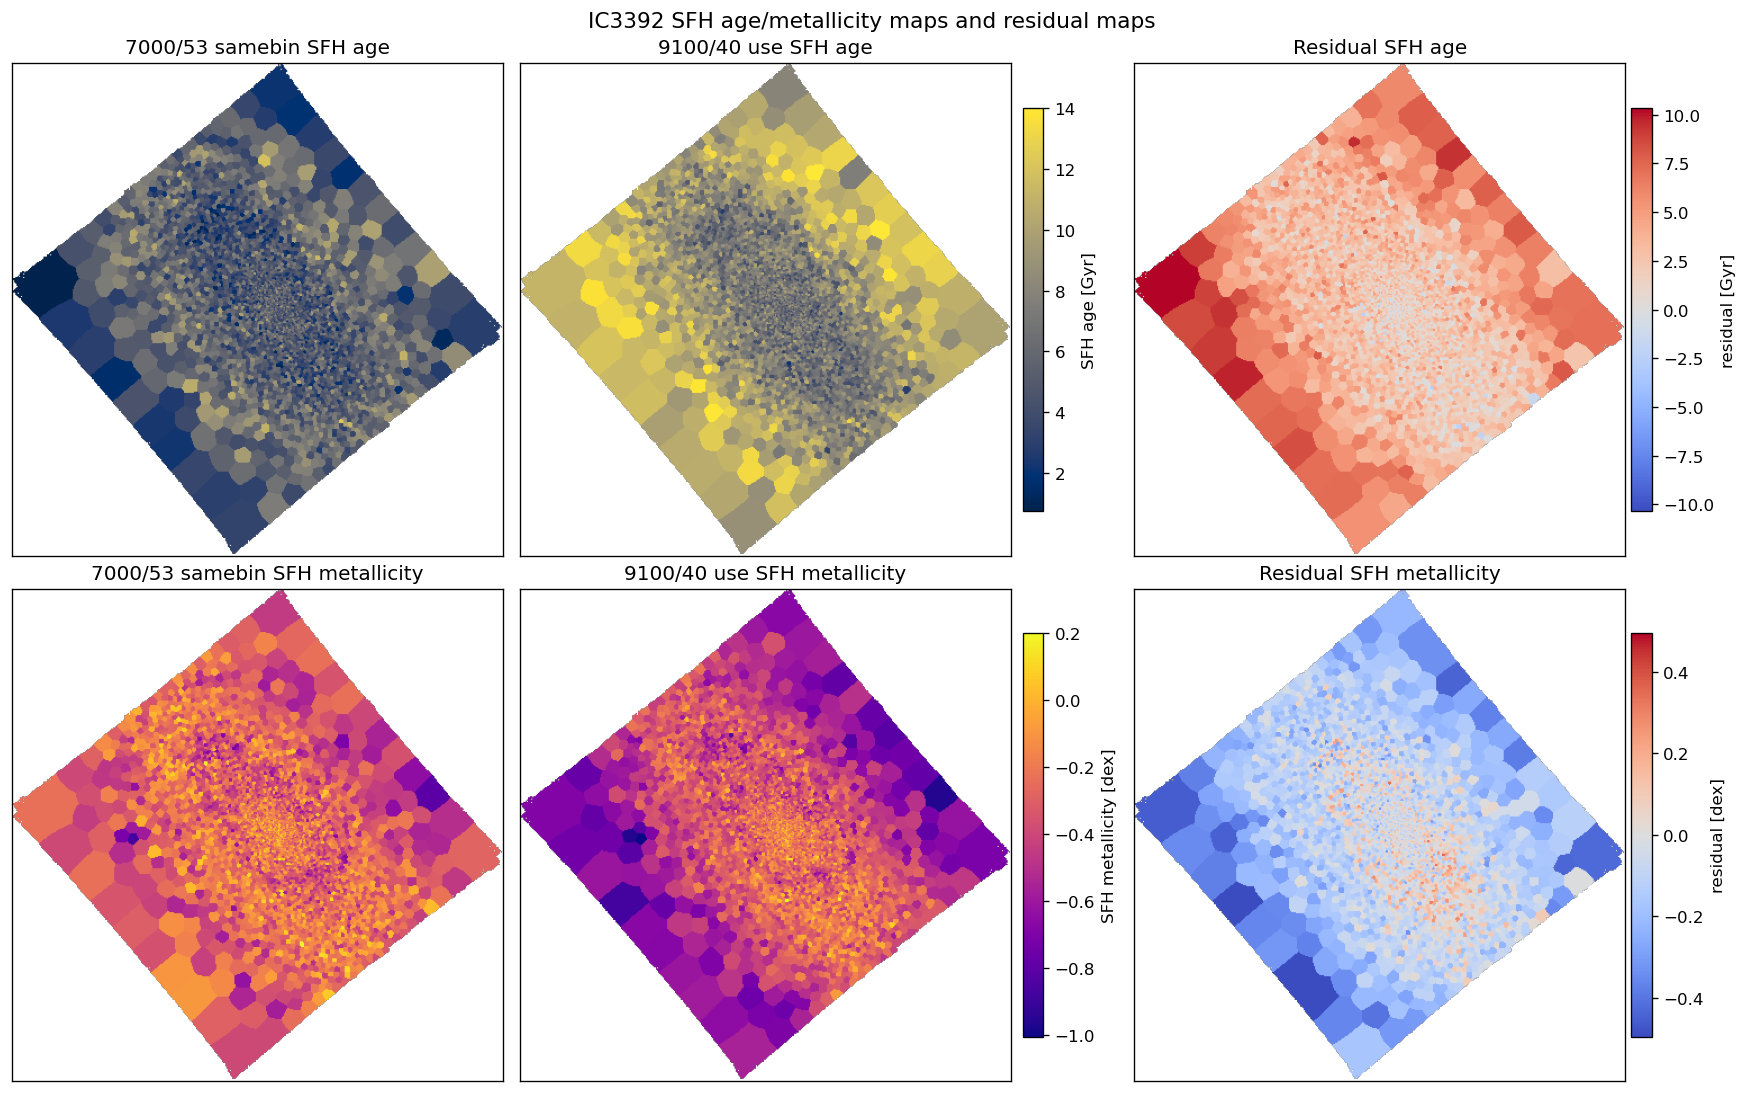

In [12]:
SFH_MAP_PROPERTIES = {
    'AGE': {
        'label': 'SFH age',
        'unit': 'Gyr',
        'cmap': 'cividis',
    },
    'METAL': {
        'label': 'SFH metallicity',
        'unit': 'dex',
        'cmap': 'plasma',
    },
}

sfh_map_data = {run_key: {} for run_key in MAP_ORDER}
for run_key in MAP_ORDER:
    sfh_path = RUNS[run_key]['path'] / RUNS[run_key]['sfh_file']
    for prop_key in SFH_MAP_PROPERTIES:
        sfh_map_data[run_key][prop_key], _ = read_image(sfh_path, prop_key)


def per_bin_sfh_map_table(prop_key):
    test = sfh_map_data[TEST_KEY][prop_key]
    ref = sfh_map_data[REF_KEY][prop_key]
    test_bin = data[TEST_KEY]['BINID']
    ref_bin = data[REF_KEY]['BINID']
    finite = np.isfinite(test) & np.isfinite(ref) & np.isfinite(test_bin) & np.isfinite(ref_bin)

    if binid_same:
        finite = finite & (test_bin == ref_bin)
        raw = pd.DataFrame({
            'binid': test_bin[finite].astype(int),
            'test': test[finite],
            'ref': ref[finite],
        })
        grouped = raw.groupby('binid', sort=True).agg(
            test=('test', 'median'),
            ref=('ref', 'median'),
            n_pixels=('test', 'size'),
        ).reset_index()
        grouped['comparison_unit'] = 'matched_bin'
    else:
        yy, xx = np.where(finite)
        grouped = pd.DataFrame({
            'x': xx,
            'y': yy,
            'binid_test': test_bin[finite].astype(int),
            'binid_ref': ref_bin[finite].astype(int),
            'test': test[finite],
            'ref': ref[finite],
            'n_pixels': 1,
            'comparison_unit': 'common_pixel',
        })

    grouped['residual'] = grouped['test'] - grouped['ref']
    return grouped

sfh_map_tables = {prop_key: per_bin_sfh_map_table(prop_key) for prop_key in SFH_MAP_PROPERTIES}

sfh_map_summary_rows = []
for prop_key, prop in SFH_MAP_PROPERTIES.items():
    table = sfh_map_tables[prop_key]
    residual = table['residual'].to_numpy(dtype=float)
    sfh_map_summary_rows.append({
        'property': prop['label'],
        'unit': prop['unit'],
        'comparison_basis': COMPARISON_BASIS,
        'n_comparison_points': len(table),
        f"median_{RUNS[REF_KEY]['label']}": np.nanmedian(table['ref']),
        f"median_{RUNS[TEST_KEY]['label']}": np.nanmedian(table['test']),
        'median_residual_use_minus_samebin': np.nanmedian(residual),
        'mean_residual_use_minus_samebin': np.nanmean(residual),
        'nmad_residual': nmad(residual),
        'p16_residual': np.nanpercentile(residual, 16),
        'p84_residual': np.nanpercentile(residual, 84),
        'corrcoef': np.corrcoef(table['ref'], table['test'])[0, 1],
        'n_positive_residual': int((residual > 0).sum()),
        'n_negative_residual': int((residual < 0).sum()),
    })

sfh_map_summary = pd.DataFrame(sfh_map_summary_rows)
display(sfh_map_summary)

fig, axes = plt.subplots(len(SFH_MAP_PROPERTIES), 3, figsize=(14.5, 9.0), constrained_layout=True)
if axes.ndim == 1:
    axes = axes[None, :]

for row, (prop_key, prop) in enumerate(SFH_MAP_PROPERTIES.items()):
    ref = sfh_map_data[REF_KEY][prop_key]
    test = sfh_map_data[TEST_KEY][prop_key]
    combined = np.concatenate([ref.ravel(), test.ravel()])
    vmin, vmax = finite_limits(combined)

    im0 = axes[row, 0].imshow(ref, origin='lower', cmap=prop['cmap'], vmin=vmin, vmax=vmax)
    axes[row, 0].set_title(f"{RUNS[REF_KEY]['label']} {prop['label']}")
    axes[row, 0].set_xticks([])
    axes[row, 0].set_yticks([])

    im1 = axes[row, 1].imshow(test, origin='lower', cmap=prop['cmap'], vmin=vmin, vmax=vmax)
    axes[row, 1].set_title(f"{RUNS[TEST_KEY]['label']} {prop['label']}")
    axes[row, 1].set_xticks([])
    axes[row, 1].set_yticks([])
    fig.colorbar(im1, ax=axes[row, :2], shrink=0.82, pad=0.012, label=f"{prop['label']} [{prop['unit']}]")

    residual = test - ref
    rmin, rmax = symmetric_limits(residual)
    im2 = axes[row, 2].imshow(residual, origin='lower', cmap='coolwarm', vmin=rmin, vmax=rmax)
    axes[row, 2].set_title(f"Residual {prop['label']}")
    axes[row, 2].set_xticks([])
    axes[row, 2].set_yticks([])
    fig.colorbar(im2, ax=axes[row, 2], shrink=0.82, pad=0.012, label=f"residual [{prop['unit']}]")

fig.suptitle('IC3392 SFH age/metallicity maps and residual maps', fontsize=13)
plt.show()

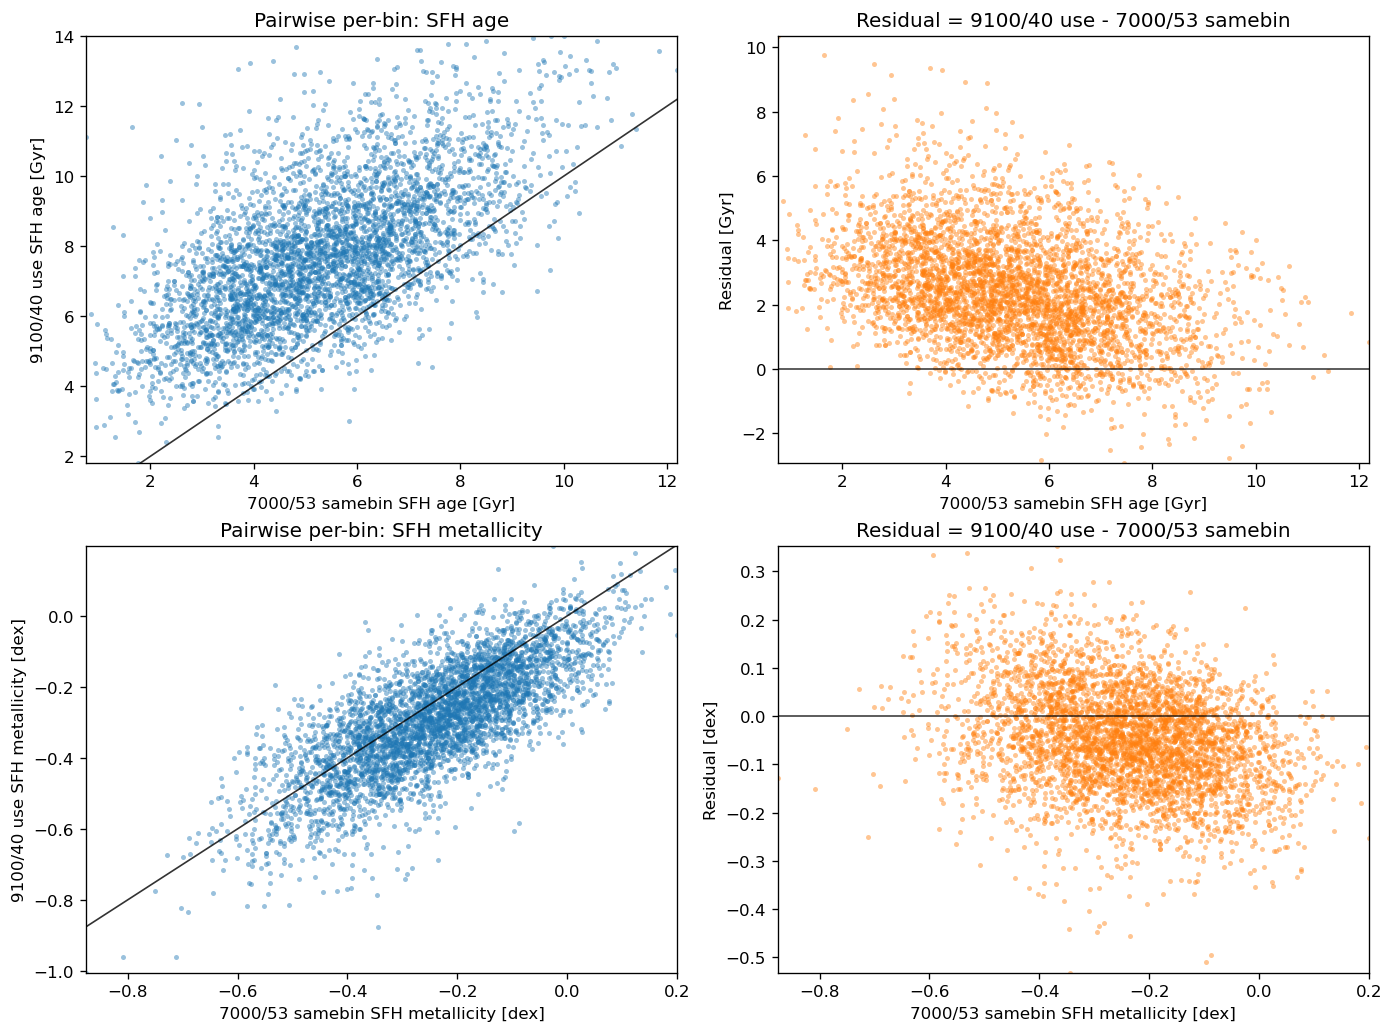

In [13]:
fig, axes = plt.subplots(len(SFH_MAP_PROPERTIES), 2, figsize=(11.5, 8.5), constrained_layout=True)
if axes.ndim == 1:
    axes = axes[None, :]

for row, (prop_key, prop) in enumerate(SFH_MAP_PROPERTIES.items()):
    table = sfh_map_tables[prop_key]
    x = table['ref'].to_numpy(dtype=float)
    y = table['test'].to_numpy(dtype=float)
    residual = table['residual'].to_numpy(dtype=float)

    ax = axes[row, 0]
    ax.scatter(x, y, s=9, alpha=0.45, linewidths=0, color='tab:blue')
    xlo, xhi = finite_limits(x)
    ylo, yhi = finite_limits(y)
    line_lo = min(xlo, ylo)
    line_hi = max(xhi, yhi)
    ax.plot([line_lo, line_hi], [line_lo, line_hi], color='black', lw=1.0, alpha=0.8)
    ax.set_xlim(xlo, xhi)
    ax.set_ylim(ylo, yhi)
    ax.set_xlabel(f"{RUNS[REF_KEY]['label']} {prop['label']} [{prop['unit']}]")
    ax.set_ylabel(f"{RUNS[TEST_KEY]['label']} {prop['label']} [{prop['unit']}]")
    ax.set_title(f"Pairwise per-bin: {prop['label']}")

    ax = axes[row, 1]
    ax.axhline(0, color='black', lw=1.0, alpha=0.75)
    ax.scatter(x, residual, s=9, alpha=0.45, linewidths=0, color='tab:orange')
    xlo, xhi = finite_limits(x)
    ylo, yhi = finite_limits(residual)
    ax.set_xlim(xlo, xhi)
    ax.set_ylim(ylo, yhi)
    ax.set_xlabel(f"{RUNS[REF_KEY]['label']} {prop['label']} [{prop['unit']}]")
    ax.set_ylabel(f"Residual [{prop['unit']}]")
    ax.set_title(f"Residual = {RUNS[TEST_KEY]['label']} - {RUNS[REF_KEY]['label']}")

plt.show()

## Integrated Mass-Log Values

These values are parsed directly from each run's `mass_logs/<galaxy>.log`. The comparison column is `9100/40 use - 7000/53 samebin`.

In [14]:
INTEGRATED_METRIC_ROWS = [
    ('Total R-band magnitude (uncorrected)', 'total_R_mag_uncorrected_AB', 'mag AB'),
    ('Total R-band magnitude (corrected)', 'total_R_mag_corrected_AB', 'mag AB'),
    ('Total R-band luminosity', 'total_R_luminosity_log10_Lsun', 'log10(Lsun)'),
    ('Total stellar mass (R)', 'total_stellar_mass_log10_Msun', 'log10(Msun)'),
    ('Integrated stellar M/L_R', 'integrated_ML_R_Msun_per_Lsun', 'Msun/Lsun'),
]

integrated_rows = []
for label, key, unit in INTEGRATED_METRIC_ROWS:
    value_samebin = log_summary.loc[RUNS[REF_KEY]['label'], key]
    value_use = log_summary.loc[RUNS[TEST_KEY]['label'], key]
    integrated_rows.append({
        'quantity': label,
        RUNS[REF_KEY]['label']: value_samebin,
        RUNS[TEST_KEY]['label']: value_use,
        f"{RUNS[TEST_KEY]['label']} - {RUNS[REF_KEY]['label']}": value_use - value_samebin,
        'unit': unit,
    })

integrated_log_values = pd.DataFrame(integrated_rows)
display(integrated_log_values)


,quantity,7000/53 samebin,9100/40 use,9100/40 use - 7000/53 samebin,unit
0,Total R-band magnitude (uncorrected),12.2600,12.2600,0.000,mag AB
1,Total R-band magnitude (corrected),11.8650,12.0770,0.212,mag AB
2,Total R-band luminosity,9.5330,9.4480,-0.085,log10(Lsun)
3,Total stellar mass (R),9.7210,9.7790,0.058,log10(Msun)
4,Integrated stellar M/L_R,1.5402,2.1402,0.600,Msun/Lsun


## Observation And Interpretation

### Observation

The two products are directly comparable on a bin-by-bin basis. The `BINID` maps match exactly, including the NaN mask, and both runs contain `4032` common finite bins. The residuals below therefore trace changes in the fitted SFH/dust/mass products, not a binning mismatch.

For `E(B-V)`, the two maps have very similar spatial structure, but the `9100/40 use` run is systematically lower than the `7000/53 samebin` run. The per-bin correlation is `0.931`, so the dust pattern is largely preserved, but the median value shifts from `0.1168 mag` in `7000/53 samebin` to `0.0560 mag` in `9100/40 use`. The median residual, defined as `9100/40 use - 7000/53 samebin`, is `-0.06045 mag`, with a 16th to 84th percentile range of `-0.0900` to `-0.0353 mag`. Almost all common bins move downward: `3986 / 4032` bins have negative residuals, only `7` bins are positive, and `39` are exactly zero. The largest negative residual is about `-0.156 mag`, while the largest positive residual is only about `+0.016 mag`.

For `LOGMASS_SURFACE_DENSITY`, the spatial morphology is also strongly preserved, with a per-bin correlation of `0.972`, but the residual is not centered on zero. The median surface density changes from `8.2787 dex` in `7000/53 samebin` to `8.3433 dex` in `9100/40 use`. The median residual is `+0.04057 dex`, with a 16th to 84th percentile range of `-0.0460` to `+0.1447 dex`. Most bins are higher in the `9100/40 use` run: `2700 / 4032` bins are positive and `1332 / 4032` are negative. The residual distribution has a longer positive tail, reaching about `+0.726 dex`, while the most negative residual is about `-0.294 dex`.

The integrated quantities in `mass_logs/IC3392.log` support the same picture. The uncorrected total R-band magnitude is identical in the two logs, `12.260 AB`, so the input photometric normalization is not changing at that level. After extinction correction, however, `9100/40 use` is fainter: `12.077 AB` compared with `11.865 AB`, giving a lower total R-band luminosity by `0.085 dex`. Despite this lower corrected luminosity, the total stellar mass is higher in `9100/40 use` by `0.058 dex`, because the integrated `M/L_R` is much higher: `2.1402` compared with `1.5402 M_sun/L_sun`.

The new SFH-weight-grid check explains why the mass-to-light ratio changes. The template grids match, with `53` `LOGAGE` bins, `9` metallicity bins, and only one `ALPHA` value. Averaging the normalized SFH weights over bins, the `9100/40 use` run shifts toward older templates: the mean linear age from the weight grid increases from `5.321 Gyr` to `7.750 Gyr`, and the fraction of weight at ages `>= 8 Gyr` increases from `0.367` to `0.570`. The largest positive weight residuals are concentrated in old cells, including `LOGAGE = 1.0969, METAL = 0.26` and `LOGAGE = 1.1461` at both very low and high metallicity. Conversely, several negative residual cells are around younger/intermediate ages near `LOGAGE ~ 0.0-0.1` and solar-ish metallicity.

The spatial `AGE` and `METAL` maps show the same trend. The median fitted age increases from `5.242 Gyr` in `7000/53 samebin` to `7.638 Gyr` in `9100/40 use`, with a median residual of `+2.324 Gyr`; `3770 / 4032` bins are older in the `9100/40 use` run. The median metallicity decreases from `-0.238 dex` to `-0.286 dex`, with a median residual of `-0.0498 dex`; `2757 / 4032` bins are more metal-poor in the `9100/40 use` run. Age is therefore the stronger coherent shift, while metallicity also moves slightly lower.

### Interpretation

The dominant difference between the runs is a coherent SFH/dust solution shift, not a random spatial failure. Because the binning and uncorrected R-band magnitude agree, the offsets are unlikely to be caused by different spatial bins or a different raw photometric scale. They are more naturally explained by the fitted stellar-population and attenuation solution changing between the `9100/40 use` and `7000/53 samebin` setups.

The `9100/40 use` run fits substantially lower dust reddening almost everywhere. Lower `E(B-V)` means a smaller extinction correction to the R-band light, which explains why the corrected R-band luminosity is lower in the log summary even though the uncorrected magnitude is unchanged. At the same time, the `9100/40 use` SFH solution shifts strongly toward older templates and gives a higher stellar `M/L_R`. That older-weight shift more than compensates for the lower corrected luminosity, so the integrated stellar mass becomes higher by `0.058 dex` and the median mass surface density is higher by `0.0406 dex`.

This means the SFH-weight heatmap is useful: it shows the mechanism behind the dust/mass offset. A reasonable working hypothesis is that extending the fitted wavelength range to the red end and using the `9100/40 use` configuration changes the age-metallicity-dust balance of the stellar-population fit. The run appears to trade some dust attenuation and slightly lower fitted metallicity for older stellar ages and a higher mass-to-light ratio. This is internally consistent with the lower `E(B-V)`, lower dust-corrected luminosity, higher `M/L_R`, older age map, and higher stellar mass. The large positive local surface-density residuals should still be inspected spatially, especially where the affected bins are large or low-surface-brightness, but they sit on top of a clear global SFH offset rather than defining the whole result.

Note that `E(B-V)` is reported here in magnitudes of color excess, `AGE` is in Gyr, and `LOGMASS_SURFACE_DENSITY` and `METAL` are in dex-like additive units. Their residuals are simple subtractions, always `9100/40 use - 7000/53 samebin`.

## Notes For Reading This Notebook

- The first figure is the requested 2x2 product-map view, with one shared colorbar per property row.
- Pairwise and residual scatter plots use one point per spatial bin.
- Residual maps use the image grids directly and show `9100/40 use - 7000/53 samebin`.
- The parsed mass-log table is included because integrated stellar mass and M/L can shift even when the maps look spatially similar.

In [15]:
# Optional exports if needed later.
# residual_summary.to_csv('IC3392_SFH_mass_residual_summary_20260518.csv', index=False)
# log_summary.to_csv('IC3392_mass_log_summary_20260518.csv')